## 16. 데이터 체크 단계 정리

이 노트북에서 확인한 내용은 다음과 같다.

- 원본 CSV가 정상적으로 불러와짐
- 컬럼 구조와 데이터 타입 확인 완료
- 결측치 / 중복치 / 빈 리뷰 점검 완료
- 날짜 파싱 가능 여부 확인 완료
- 전처리 모듈 실행 확인 완료
- `df_text`, `df_time` 생성 확인 완료
- 품질 점검표 / 요약 통계표 / 날짜별 추이표 / 이미지 비교표 생성 확인 완료

이제 다음 단계에서는 `02_text_eda_baseline.ipynb`에서 본격적으로 다음을 수행할 수 있다.

- 리뷰 수 집계 및 시각화
- 날짜별 추이 시각화
- 리뷰 길이 분석
- 단어 빈도
- TF-IDF
- n-gram
- 샘플 기반 토픽 탐색

In [1]:
from pathlib import Path
import sys
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [2]:
# 출력 옵션
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 200)

# matplotlib 한글 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

## 1. 프로젝트 경로 설정

이 노트북은 `project/notebooks/` 폴더 안에 위치한다고 가정한다.  
따라서 상위 폴더인 `project/`를 기준 경로로 잡고,  
전처리된 CSV 및 결과 저장 폴더 경로를 설정한다.

현재는 체크포인트 파일 기반 전처리 결과를 사용하지만,  
향후 최종 파일(`cgv_reviews_final.csv`)로 다시 전처리한 뒤에도  
동일한 구조로 이어서 사용할 수 있다.

In [3]:
CURRENT_DIR = Path.cwd().resolve()

# 현재 노트북이 cgv_review_project/notebooks 안에서 실행된다고 가정
if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
# 혹시 프로젝트 루트에서 직접 실행하는 경우
elif (CURRENT_DIR / "data").exists() and (CURRENT_DIR / "outputs").exists():
    PROJECT_ROOT = CURRENT_DIR
else:
    raise FileNotFoundError(
        "프로젝트 루트를 찾지 못했습니다. "
        "노트북을 cgv_review_project 또는 cgv_review_project/notebooks 기준으로 실행해주세요."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROCESSED_TEXT_PATH = PROJECT_ROOT / "data" / "processed" / "reviews_cleaned_text.csv"
PROCESSED_TIME_PATH = PROJECT_ROOT / "data" / "processed" / "reviews_cleaned_time.csv"

FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("CURRENT_DIR :", CURRENT_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("FIGURE_DIR  :", FIGURE_DIR)
print("TABLE_DIR   :", TABLE_DIR)

CURRENT_DIR : C:\Users\USER\Desktop\cgv_review_project\notebooks
PROJECT_ROOT: C:\Users\USER\Desktop\cgv_review_project
FIGURE_DIR  : C:\Users\USER\Desktop\cgv_review_project\outputs\figures
TABLE_DIR   : C:\Users\USER\Desktop\cgv_review_project\outputs\tables


## 2. 전처리 데이터 불러오기

앞서 `clean_reviews.py` 실행 결과로 저장된 전처리 데이터를 불러온다.

- `df_text` : 전체 텍스트 분석용 데이터  
  - 부분 수집일 포함
- `df_time` : 날짜별 추이 분석용 데이터  
  - 부분 수집일 제외

즉, 텍스트 자체를 분석할 때는 `df_text`,  
날짜별 추이를 볼 때는 `df_time`을 주로 사용한다.

In [4]:
df_text = pd.read_csv(PROCESSED_TEXT_PATH)
df_time = pd.read_csv(PROCESSED_TIME_PATH)

print("df_text shape:", df_text.shape)
print("df_time shape:", df_time.shape)

df_text shape: (46599, 27)
df_time shape: (46596, 27)


In [5]:
df_text.head()

,review_id,movie_no,movie_name,author,date,score,like_count,review,movie_kind,has_image,api_start_row,dt,review_date,review_year,review_month,review_day,review_hour,review_weekday,sentiment_label,is_positive,is_negative,has_image_flag,review_length,word_count,like_bin,is_partial_day,like_count_within_date_rank_pct
0,38249521,30000927,왕과 사는 남자,영화에도라버린학생,2026-03-30 00:16:23,2,0,기대하고 봤는데 기대한 만큼 좋았음 마지막이 아쉬웠는데\n스토리 특성상 원래 있던 내용을 기본으로 깔고가는거라 \n이해됐음ㅁㅁ,2D 일반,N,0,2026-03-30 00:16:23,2026-03-30,2026,3,30,0,Monday,좋았어요,1,0,0,68,15,0,1,0.666667
1,38249497,30000927,왕과 사는 남자,용감한할리퀸28348,2026-03-30 00:03:06,2,0,많이 울고 많이 웃었습니다.\n마음이 너무 짠한영화,2D 일반,N,0,2026-03-30 00:03:06,2026-03-30,2026,3,30,0,Monday,좋았어요,1,0,0,27,7,0,1,0.666667
2,38249493,30000927,왕과 사는 남자,평화로운뮬란676352,2026-03-30 00:02:07,2,0,특히 마지막 단종의삶을 그대로 표현해낸\n배우들의 연기에 몰입하고 왕의 자리의 힘듬을 잘 그려낸영화입니다,2D 일반,N,0,2026-03-30 00:02:07,2026-03-30,2026,3,30,0,Monday,좋았어요,1,0,0,63,13,0,1,0.666667
3,38249460,30000927,왕과 사는 남자,행복햄덩이,2026-03-29 23:48:13,2,0,박지훈의 무게감 있는 왕 연기 최고였고 유해진님과의 케미도 너무 좋아서 재밌고 감동깊게 잘 봤습니다\n좋은 작품 보여주셔서 감사합니다,2D 일반,N,0,2026-03-29 23:48:13,2026-03-29,2026,3,29,23,Sunday,좋았어요,1,0,0,73,18,0,0,0.116788
4,38249448,30000927,왕과 사는 남자,완벽한덤보11733,2026-03-29 23:45:05,2,0,단종과 '엄흥도'의 이야기를 이렇게 풀어냈다는게 참 대단하다는 생각이든다.\n다만 나와 영화의 깊이와 속도가 맞지않아 조금 아쉬웠고 이렇게이렇게 흥행한다고? 싶은 생각도 들었다,2D 일반,N,0,2026-03-29 23:45:05,2026-03-29,2026,3,29,23,Sunday,좋았어요,1,0,0,97,21,0,0,0.116788


## 3. 기본 EDA: 전체 리뷰 수와 핵심 변수 확인

먼저 전체 데이터의 기본 규모와 주요 변수 분포를 확인한다.

여기서는 다음을 본다.

- 전체 리뷰 수
- 긍정/부정 비율
- 이미지 포함 여부
- 좋아요 수 요약
- 리뷰 길이 요약

이 단계는 데이터셋의 전체적인 성격을 빠르게 파악하기 위한 기초 요약 단계이다.

In [6]:
summary_overview = {
    "total_reviews": len(df_text),
    "positive_reviews": int((df_text["score"] == 2).sum()),
    "negative_reviews": int((df_text["score"] == 1).sum()),
    "positive_ratio": round((df_text["score"] == 2).mean(), 4),
    "negative_ratio": round((df_text["score"] == 1).mean(), 4),
    "image_review_count": int((df_text["has_image"] == "Y").sum()),
    "image_review_ratio": round((df_text["has_image"] == "Y").mean(), 4),
    "avg_like_count": round(df_text["like_count"].mean(), 4),
    "median_like_count": round(df_text["like_count"].median(), 4),
    "avg_review_length": round(df_text["review_length"].mean(), 4),
    "median_review_length": round(df_text["review_length"].median(), 4),
}

pd.DataFrame(summary_overview.items(), columns=["metric", "value"])

,metric,value
0,total_reviews,46599.0000
1,positive_reviews,45265.0000
2,negative_reviews,1334.0000
3,positive_ratio,0.9714
4,negative_ratio,0.0286
5,image_review_count,489.0000
6,image_review_ratio,0.0105
7,avg_like_count,0.3556
8,median_like_count,0.0000
9,avg_review_length,42.0255


In [7]:
score_dist = (
    df_text["sentiment_label"]
    .value_counts(dropna=False)
    .rename_axis("sentiment_label")
    .reset_index(name="count")
)

score_dist

,sentiment_label,count
0,좋았어요,45265
1,별로예요,1334


In [8]:
image_dist = (
    df_text["has_image"]
    .value_counts(dropna=False)
    .rename_axis("has_image")
    .reset_index(name="count")
)

image_dist

,has_image,count
0,N,46110
1,Y,489


## 4. 리뷰 수와 기본 분포 시각화

이 단계에서는 가장 기본적인 분포를 간단한 막대그래프와 히스토그램으로 확인한다.

복잡한 시각화보다, 현재 데이터 구조를 직관적으로 파악할 수 있는  
기초적인 그래프를 우선 그린다.

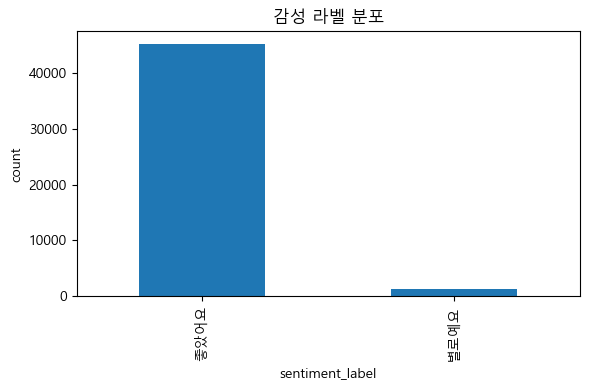

In [9]:
score_counts = df_text["sentiment_label"].value_counts()

plt.figure(figsize=(6, 4))
score_counts.plot(kind="bar")
plt.title("감성 라벨 분포")
plt.xlabel("sentiment_label")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

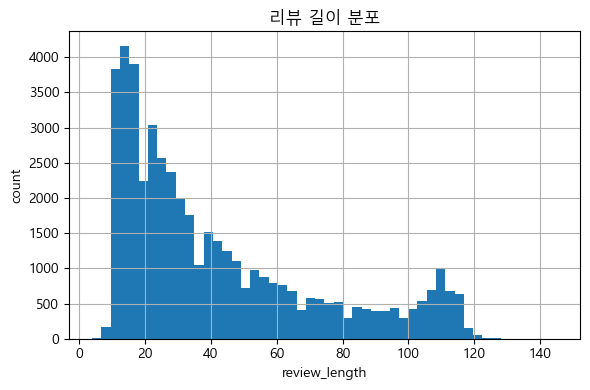

In [10]:
plt.figure(figsize=(6, 4))
df_text["review_length"].hist(bins=50)
plt.title("리뷰 길이 분포")
plt.xlabel("review_length")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "review_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

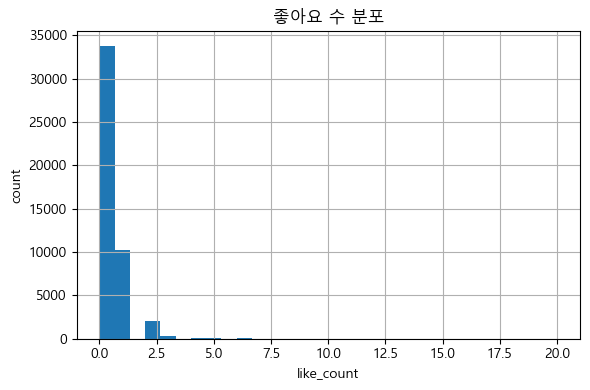

In [11]:
plt.figure(figsize=(6, 4))
df_text["like_count"].hist(bins=30)
plt.title("좋아요 수 분포")
plt.xlabel("like_count")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "like_count_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. 날짜별 추이 분석

날짜별 추이는 `df_time`을 기준으로 본다.  
그 이유는 `df_time`이 부분 수집일을 제외한 데이터이기 때문이다.

여기서는 다음을 확인한다.

- 날짜별 리뷰 수
- 날짜별 긍정 비율
- 날짜별 평균 리뷰 길이

이는 전체 리뷰 흐름과 작성 분위기의 일별 변화를 파악하기 위한 단계이다.

In [12]:
daily_trend = (
    df_time.groupby("review_date", as_index=False)
    .agg(
        review_count=("review_id", "count"),
        positive_ratio=("is_positive", "mean"),
        avg_review_length=("review_length", "mean"),
        avg_like_count=("like_count", "mean"),
    )
    .sort_values("review_date")
)

daily_trend.head(55)

,review_date,review_count,positive_ratio,avg_review_length,avg_like_count
0,2026-02-07,1195,0.975732,43.514644,0.235146
1,2026-02-08,2395,0.980376,43.148225,0.309395
2,2026-02-09,1315,0.968061,40.619772,0.318631
3,2026-02-10,1129,0.967228,40.311780,0.396811
4,2026-02-11,1091,0.971586,40.234647,0.390467
5,2026-02-12,979,0.975485,42.346272,0.454545
6,2026-02-13,869,0.974684,41.361335,0.325662
7,2026-02-14,1507,0.974784,40.814864,0.469144
8,2026-02-15,1794,0.980491,41.765329,0.311594
9,2026-02-16,1908,0.971174,40.529350,0.286164


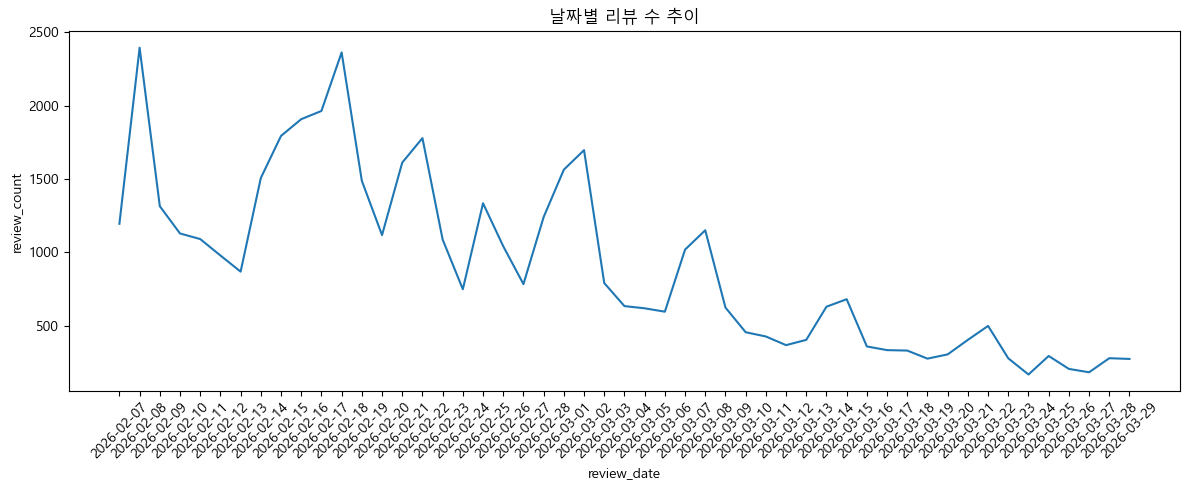

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(daily_trend["review_date"], daily_trend["review_count"])
plt.title("날짜별 리뷰 수 추이")
plt.xlabel("review_date")
plt.ylabel("review_count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "review_count_by_date.png", dpi=150, bbox_inches="tight")
plt.show()

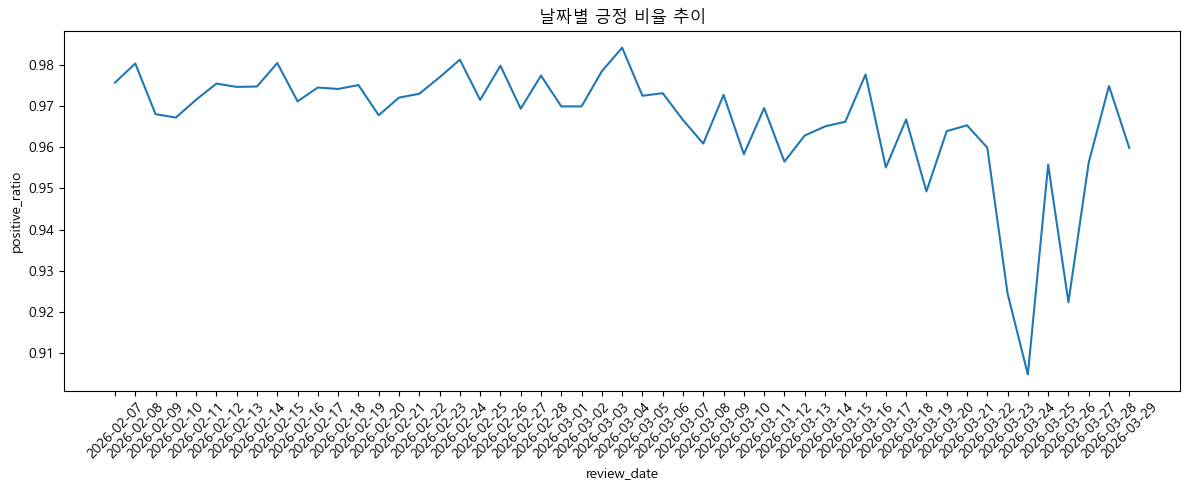

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(daily_trend["review_date"], daily_trend["positive_ratio"])
plt.title("날짜별 긍정 비율 추이")
plt.xlabel("review_date")
plt.ylabel("positive_ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "positive_ratio_by_date.png", dpi=150, bbox_inches="tight")
plt.show()

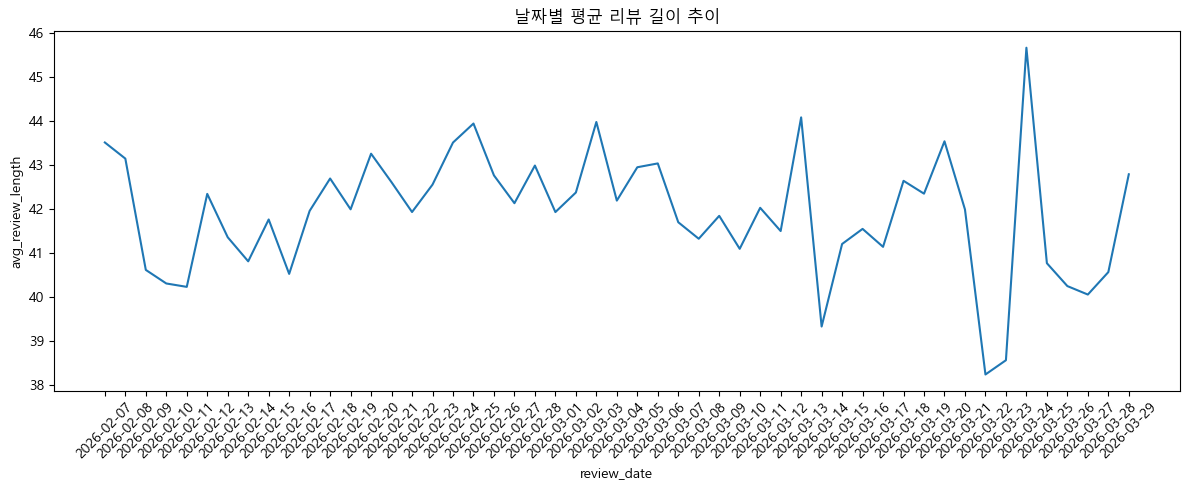

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(daily_trend["review_date"], daily_trend["avg_review_length"])
plt.title("날짜별 평균 리뷰 길이 추이")
plt.xlabel("review_date")
plt.ylabel("avg_review_length")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "avg_review_length_by_date.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. 리뷰 길이 분석

리뷰 길이는 EDA에서 매우 중요한 변수다.  
짧은 리뷰는 즉각적인 반응, 긴 리뷰는 보다 상세한 감상일 가능성이 있다.

여기서는 다음을 확인한다.

- 전체 리뷰 길이의 기초 통계
- score별 리뷰 길이 차이
- has_image 여부에 따른 길이 차이
- 길이 구간별 분포

이 분석은 이후 텍스트 특성 비교의 기초가 된다.

In [16]:
df_text["review_length"].describe()

count    46599.000000
mean        42.025451
std         30.286330
min          4.000000
25%         18.000000
50%         31.000000
75%         58.000000
max        145.000000
Name: review_length, dtype: float64

In [17]:
length_by_score = (
    df_text.groupby("sentiment_label", as_index=False)
    .agg(
        review_count=("review_id", "count"),
        avg_review_length=("review_length", "mean"),
        median_review_length=("review_length", "median"),
        avg_like_count=("like_count", "mean"),
    )
)

length_by_score

,sentiment_label,review_count,avg_review_length,median_review_length,avg_like_count
0,별로예요,1334,46.857571,34.0,1.520240
1,좋았어요,45265,41.883044,31.0,0.321242


In [18]:
length_by_image = (
    df_text.groupby("has_image", as_index=False)
    .agg(
        review_count=("review_id", "count"),
        avg_review_length=("review_length", "mean"),
        median_review_length=("review_length", "median"),
        positive_ratio=("is_positive", "mean"),
        avg_like_count=("like_count", "mean"),
    )
)

length_by_image

,has_image,review_count,avg_review_length,median_review_length,positive_ratio,avg_like_count
0,N,46110,41.829234,31.0,0.971134,0.355086
1,Y,489,60.527607,55.0,0.993865,0.400818


In [19]:
# 리뷰 길이 구간화
df_text["length_bin"] = pd.cut(
    df_text["review_length"],
    bins=[0, 10, 20, 50, 100, 200, 500, np.inf],
    labels=["1-10", "11-20", "21-50", "51-100", "101-200", "201-500", "500+"],
    include_lowest=True
)

length_bin_dist = (
    df_text["length_bin"]
    .value_counts()
    .sort_index()
    .rename_axis("length_bin")
    .reset_index(name="count")
)

length_bin_dist

,length_bin,count
0,1-10,1207
1,11-20,13125
2,21-50,18381
3,51-100,9864
4,101-200,4022
5,201-500,0
6,500+,0


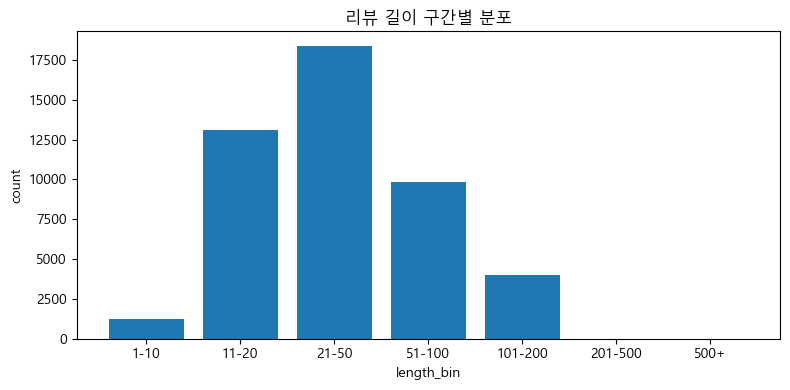

In [20]:
plt.figure(figsize=(8, 4))
plt.bar(length_bin_dist["length_bin"].astype(str), length_bin_dist["count"])
plt.title("리뷰 길이 구간별 분포")
plt.xlabel("length_bin")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "review_length_bin_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. has_image 비교

이미지 포함 리뷰는 전체에서 비중이 매우 크지 않지만,  
탐색적 수준에서 다음을 확인할 가치는 있다.

- 이미지 포함 리뷰가 더 긍정적인가
- 이미지 포함 리뷰가 더 긴가
- 이미지 포함 리뷰가 더 많은 좋아요를 받는가

다만 표본 수 차이가 크므로,  
해석은 “경향 확인” 수준에 그친다.

In [21]:
image_compare = (
    df_text.groupby("has_image", as_index=False)
    .agg(
        review_count=("review_id", "count"),
        positive_ratio=("is_positive", "mean"),
        avg_review_length=("review_length", "mean"),
        median_review_length=("review_length", "median"),
        avg_like_count=("like_count", "mean"),
        median_like_count=("like_count", "median"),
    )
)

image_compare

,has_image,review_count,positive_ratio,avg_review_length,median_review_length,avg_like_count,median_like_count
0,N,46110,0.971134,41.829234,31.0,0.355086,0.0
1,Y,489,0.993865,60.527607,55.0,0.400818,0.0


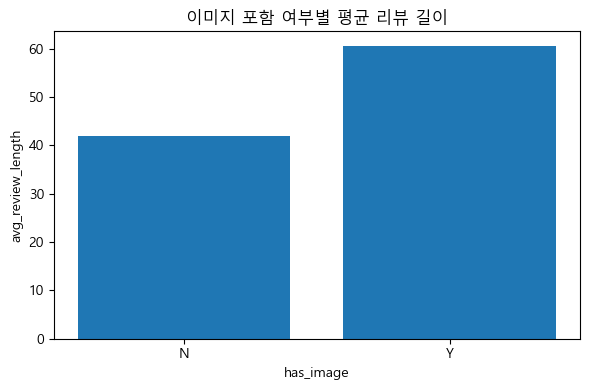

In [22]:
plt.figure(figsize=(6, 4))
plt.bar(image_compare["has_image"], image_compare["avg_review_length"])
plt.title("이미지 포함 여부별 평균 리뷰 길이")
plt.xlabel("has_image")
plt.ylabel("avg_review_length")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "image_vs_avg_review_length.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. 텍스트 정규화 준비

이제 단어 빈도, TF-IDF, n-gram 분석을 위해  
리뷰 텍스트를 간단히 정규화한다.

현재 단계에서는 무거운 형태소 분석기 대신  
가벼운 텍스트 정리 방식을 우선 사용한다.

주요 처리 내용은 다음과 같다.

- 소문자 변환
- 특수문자 제거
- 숫자 제거
- 연속 공백 정리

한국어 텍스트 특성상 완벽한 전처리는 아니지만,  
현재 8GB 환경에서 빠르게 기초 분석을 진행하기에는 충분한 출발점이다.

In [23]:
STOPWORDS_PATH = PROJECT_ROOT / "data" / "external" / "stopwords_ko.txt"

if STOPWORDS_PATH.exists():
    with open(STOPWORDS_PATH, "r", encoding="utf-8") as f:
        stopwords_ko = {line.strip() for line in f if line.strip()}
else:
    stopwords_ko = set()

basic_stopwords = {
    "영화", "진짜", "정말", "그냥", "너무", "진심", "완전", "약간",
    "보고", "봤는데", "봤다", "보는", "보니", "이거", "이건",
    "근데", "그리고", "에서", "으로", "하는", "있는", "없는",
    "하다", "했다", "입니다", "있는듯", "같다", "같아요", "같음"
}

stopwords = stopwords_ko | basic_stopwords

print("불용어 수:", len(stopwords))

불용어 수: 29


In [24]:
def normalize_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"[0-9]+", " ", text)
    text = re.sub(r"[^가-힣a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_text["review_normalized"] = df_text["review"].astype(str).apply(normalize_text)

df_text[["review", "review_normalized"]].head(10)

,review,review_normalized
0,기대하고 봤는데 기대한 만큼 좋았음 마지막이 아쉬웠는데\n스토리 특성상 원래 있던 내용을 기본으로 깔고가는거라 \n이해됐음ㅁㅁ,기대하고 봤는데 기대한 만큼 좋았음 마지막이 아쉬웠는데 스토리 특성상 원래 있던 내용을 기본으로 깔고가는거라 이해됐음
1,많이 울고 많이 웃었습니다.\n마음이 너무 짠한영화,많이 울고 많이 웃었습니다 마음이 너무 짠한영화
2,특히 마지막 단종의삶을 그대로 표현해낸\n배우들의 연기에 몰입하고 왕의 자리의 힘듬을 잘 그려낸영화입니다,특히 마지막 단종의삶을 그대로 표현해낸 배우들의 연기에 몰입하고 왕의 자리의 힘듬을 잘 그려낸영화입니다
3,박지훈의 무게감 있는 왕 연기 최고였고 유해진님과의 케미도 너무 좋아서 재밌고 감동깊게 잘 봤습니다\n좋은 작품 보여주셔서 감사합니다,박지훈의 무게감 있는 왕 연기 최고였고 유해진님과의 케미도 너무 좋아서 재밌고 감동깊게 잘 봤습니다 좋은 작품 보여주셔서 감사합니다
4,단종과 '엄흥도'의 이야기를 이렇게 풀어냈다는게 참 대단하다는 생각이든다.\n다만 나와 영화의 깊이와 속도가 맞지않아 조금 아쉬웠고 이렇게이렇게 흥행한다고? 싶은 생각도 들었다,단종과 엄흥도 의 이야기를 이렇게 풀어냈다는게 참 대단하다는 생각이든다 다만 나와 영화의 깊이와 속도가 맞지않아 조금 아쉬웠고 이렇게이렇게 흥행한다고 싶은 생각도 들었다
5,너무 스토리를 다 알아서 그런지 저는 소소,너무 스토리를 다 알아서 그런지 저는 소소
6,단종의 생애가 슬펏지만\n전반적인 서사를 느낄 수 있어서 좋았습니다.,단종의 생애가 슬펏지만 전반적인 서사를 느낄 수 있어서 좋았습니다
7,늦게 봤지만 알고 봤지만 계속 눈물이 나는 영화\n어린 임금이지만 마음은 얼마나 깊고 따스한지\n지금도 어디엔가 있을 것만 같은 따뜻한 사람들에게 위로가 되는 영화 참 좋았다.,늦게 봤지만 알고 봤지만 계속 눈물이 나는 영화 어린 임금이지만 마음은 얼마나 깊고 따스한지 지금도 어디엔가 있을 것만 같은 따뜻한 사람들에게 위로가 되는 영화 참 좋았다
8,볼만했어요. 강추까지는..,볼만했어요 강추까지는
9,"친정엄마, 시어머니께 효도 한방했네요. 영화보여줘 두분다 좋았다 고맙다하시네요.\n유지태, 유해진, 박지훈, 지방관리, 상긍 등 연기 짱이네요.\n장항준 검독님은 진짜 복도 많으시네요.\n🐒🐎",친정엄마 시어머니께 효도 한방했네요 영화보여줘 두분다 좋았다 고맙다하시네요 유지태 유해진 박지훈 지방관리 상긍 등 연기 짱이네요 장항준 검독님은 진짜 복도 많으시네요


## 9. 단어 빈도 분석

먼저 가장 기본적인 단어 빈도 분석을 수행한다.

여기서는 리뷰를 공백 기준으로 토큰화하고,  
불용어를 제거한 뒤 상위 단어를 집계한다.

이 분석은 다음과 같은 질문에 답하는 데 유용하다.

- 리뷰에서 자주 언급되는 핵심 단어는 무엇인가
- 영화 감상에서 반복적으로 등장하는 표현은 무엇인가
- 긍정/부정 리뷰 간 차이가 존재하는가

In [25]:
def tokenize_for_freq(text: str, stopwords: set[str]) -> list[str]:
    tokens = text.split()
    tokens = [tok for tok in tokens if tok not in stopwords and len(tok) >= 2]
    return tokens

all_tokens = []
for text in df_text["review_normalized"]:
    all_tokens.extend(tokenize_for_freq(text, stopwords))

token_counter = Counter(all_tokens)
top_keywords = pd.DataFrame(token_counter.most_common(30), columns=["keyword", "count"])
top_keywords.head(20)

,keyword,count
0,연기가,4927
1,연기,3836
2,배우들의,3703
3,유해진,3474
4,박지훈,2969
5,봤습니다,2528
6,배우들,2488
7,오랜만에,2295
8,봤어요,1946
9,좋았어요,1868


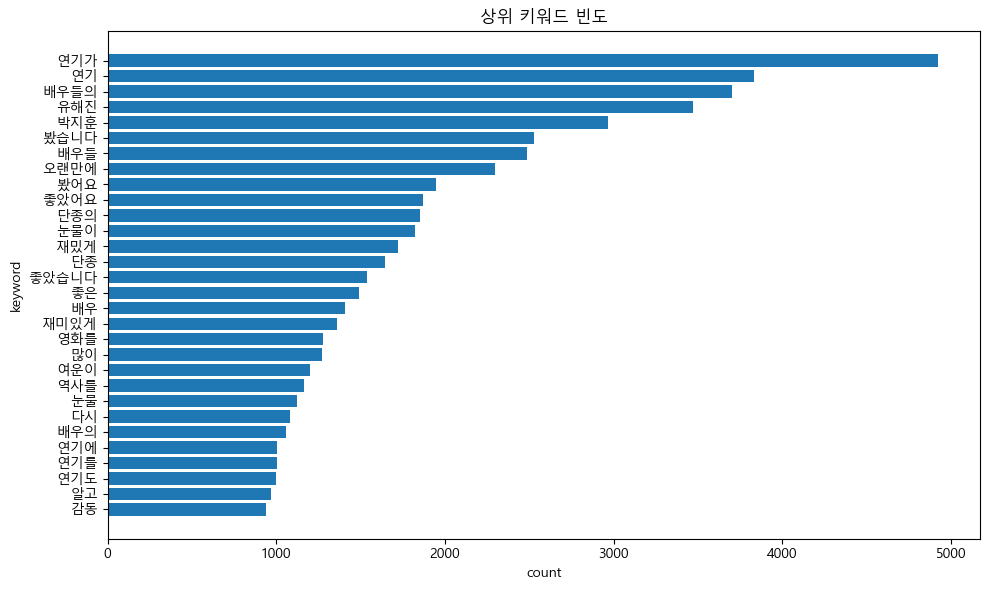

In [26]:
plt.figure(figsize=(10, 6))
plt.barh(top_keywords["keyword"][::-1], top_keywords["count"][::-1])
plt.title("상위 키워드 빈도")
plt.xlabel("count")
plt.ylabel("keyword")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "top_keywords_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. TF-IDF 분석

빈도 분석은 많이 등장한 단어를 보여주는 데 유용하지만,  
모든 문서에서 흔하게 쓰이는 단어가 상위에 올 수 있다는 한계가 있다.

TF-IDF는 각 리뷰 문서에서 상대적으로 중요한 단어를 강조하는 방식이다.  
이 노트북에서는 전체 말뭉치 기준 상위 TF-IDF 단어를 확인해  
빈도 기반 키워드와 비교해본다.

In [27]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words=list(stopwords),
    ngram_range=(1, 1),
    min_df=3,
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df_text["review_normalized"])
feature_names = tfidf_vectorizer.get_feature_names_out()

tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

tfidf_top = (
    pd.DataFrame({
        "term": feature_names,
        "tfidf_mean": tfidf_scores
    })
    .sort_values("tfidf_mean", ascending=False)
    .reset_index(drop=True)
)

tfidf_top.head(30)

,term,tfidf_mean
0,연기가,0.031887
1,연기,0.024153
2,배우들의,0.023944
3,유해진,0.022590
4,봤습니다,0.021734
5,박지훈,0.019220
6,배우들,0.017976
7,오랜만에,0.016691
8,재밌게,0.016245
9,좋았어요,0.016085


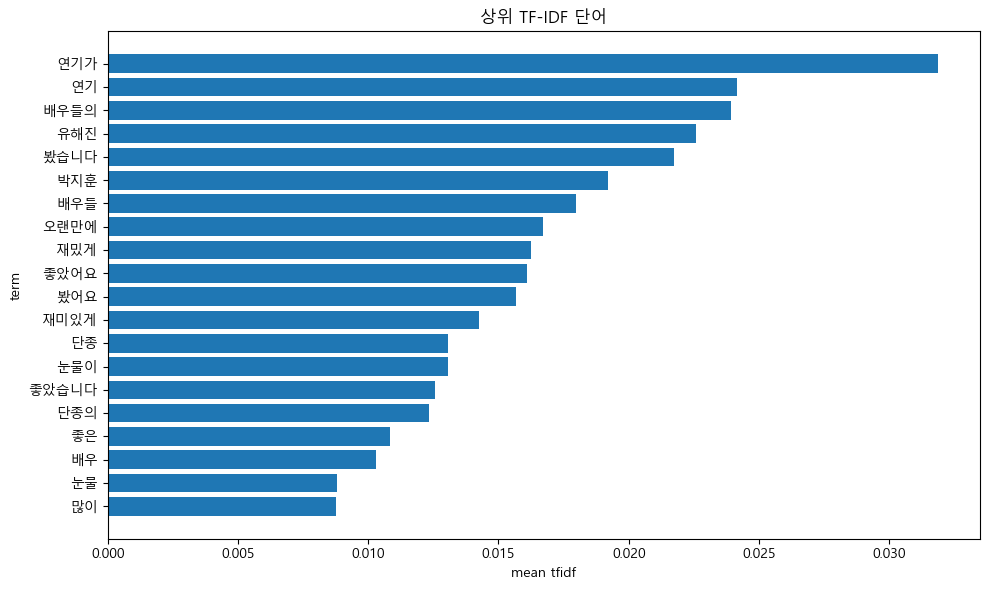

In [28]:
plt.figure(figsize=(10, 6))
top_tfidf_plot = tfidf_top.head(20).sort_values("tfidf_mean", ascending=True)
plt.barh(top_tfidf_plot["term"], top_tfidf_plot["tfidf_mean"])
plt.title("상위 TF-IDF 단어")
plt.xlabel("mean tfidf")
plt.ylabel("term")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "top_tfidf_terms.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. n-gram 분석

단일 단어만 보면 문맥이 약할 수 있다.  
따라서 2-gram, 3-gram을 통해 자주 함께 등장하는 표현을 본다.

예를 들어 다음과 같은 패턴을 파악할 수 있다.

- 자주 언급되는 인물/장면 조합
- 반복적으로 나타나는 감상 표현
- 긍정/부정 평가와 결합된 표현

현재 단계에서는 2-gram과 3-gram을 가볍게 확인한다.

In [29]:
bigram_vectorizer = CountVectorizer(
    max_features=500,
    stop_words=list(stopwords),
    ngram_range=(2, 2),
    min_df=3
)

bigram_matrix = bigram_vectorizer.fit_transform(df_text["review_normalized"])
bigram_counts = np.asarray(bigram_matrix.sum(axis=0)).ravel()
bigram_terms = bigram_vectorizer.get_feature_names_out()

bigrams_df = (
    pd.DataFrame({
        "bigram": bigram_terms,
        "count": bigram_counts
    })
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

bigrams_df.head(30)

,bigram,count
0,배우들의 연기가,1362
1,배우들 연기가,885
2,왕과 사는,540
3,재밌게 봤습니다,530
4,배우들 연기,508
5,사는 남자,481
6,연기가 좋았어요,419
7,재미있게 봤습니다,412
8,재밌게 봤어요,401
9,유해진 배우님,371


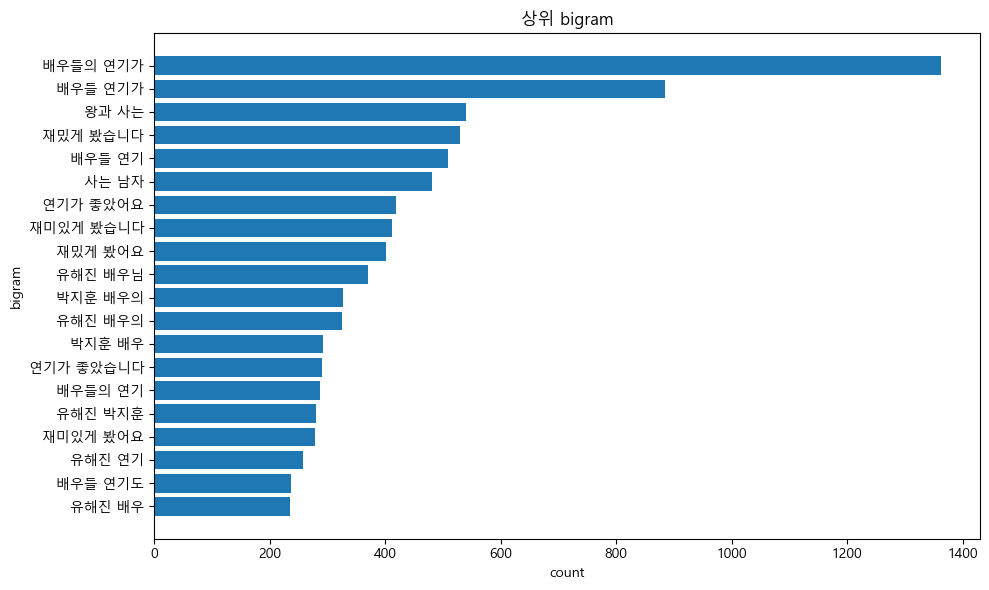

In [30]:
plt.figure(figsize=(10, 6))
bigram_plot = bigrams_df.head(20).sort_values("count", ascending=True)
plt.barh(bigram_plot["bigram"], bigram_plot["count"])
plt.title("상위 bigram")
plt.xlabel("count")
plt.ylabel("bigram")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "bigram_bar.png", dpi=150, bbox_inches="tight")
plt.show()

In [31]:
trigram_vectorizer = CountVectorizer(
    max_features=300,
    stop_words=list(stopwords),
    ngram_range=(3, 3),
    min_df=3
)

trigram_matrix = trigram_vectorizer.fit_transform(df_text["review_normalized"])
trigram_counts = np.asarray(trigram_matrix.sum(axis=0)).ravel()
trigram_terms = trigram_vectorizer.get_feature_names_out()

trigrams_df = (
    pd.DataFrame({
        "trigram": trigram_terms,
        "count": trigram_counts
    })
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

trigrams_df.head(20)

,trigram,count
0,왕과 사는 남자,466
1,배우들의 연기가 좋았어요,133
2,배우들 연기가 좋았어요,116
3,배우들의 연기가 좋았습니다,102
4,시간 가는줄 모르고,102
5,시간 가는 모르고,87
6,모든 배우들의 연기가,76
7,여운이 많이 남는,70
8,배우들의 연기가 좋았고,66
9,유해진 배우님 연기,61


## 12. score별 키워드 비교

이 데이터는 `score`가 이미 존재하므로,  
긍정 리뷰와 부정 리뷰를 나누어 자주 등장하는 단어를 비교하는 것이 중요하다.

이 단계에서는 다음을 확인한다.

- 긍정 리뷰 상위 단어
- 부정 리뷰 상위 단어
- 감성 라벨별 특징적인 표현 차이

이는 향후 더 정교한 감성 분석이나 토픽 해석의 기초 자료가 된다.

In [32]:
positive_df = df_text[df_text["score"] == 2].copy()
negative_df = df_text[df_text["score"] == 1].copy()

print("positive_df:", positive_df.shape)
print("negative_df:", negative_df.shape)

positive_df: (45265, 29)
negative_df: (1334, 29)


In [33]:
def get_top_tokens_from_series(series: pd.Series, stopwords: set[str], top_n: int = 30) -> pd.DataFrame:
    tokens = []
    for text in series:
        tokens.extend(tokenize_for_freq(text, stopwords))
    counter = Counter(tokens)
    return pd.DataFrame(counter.most_common(top_n), columns=["keyword", "count"])

positive_top = get_top_tokens_from_series(positive_df["review_normalized"], stopwords, top_n=30)
negative_top = get_top_tokens_from_series(negative_df["review_normalized"], stopwords, top_n=30)

print("[긍정 리뷰 상위 단어]")
display(positive_top)

print("[부정 리뷰 상위 단어]")
display(negative_top)

[긍정 리뷰 상위 단어]


,keyword,count
0,연기가,4867
1,연기,3765
2,배우들의,3634
3,유해진,3386
4,박지훈,2947
5,봤습니다,2520
6,배우들,2431
7,오랜만에,2286
8,봤어요,1940
9,좋았어요,1862


[부정 리뷰 상위 단어]


,keyword,count
0,연기는,95
1,유해진,88
2,연기,71
3,배우들의,69
4,연출,66
5,연기가,60
6,많이,59
7,배우들,57
8,영화가,51
9,스토리,50


In [34]:
positive_top.to_csv(TABLE_DIR / "top_keywords_positive.csv", index=False, encoding="utf-8-sig")
negative_top.to_csv(TABLE_DIR / "top_keywords_negative.csv", index=False, encoding="utf-8-sig")

## 13. 샘플 기반 토픽 탐색

현재 단계에서는 무거운 토픽 모델링 대신,  
샘플을 직접 읽고 묶어보는 방식으로 토픽을 탐색한다.

이 방식은 다음과 같은 장점이 있다.

- 계산 부담이 작다
- 실제 리뷰 맥락을 바로 읽을 수 있다
- 추후 BERTopic 결과를 해석하는 기준이 된다

여기서는 다음과 같은 샘플을 확인한다.

- 전체 상위 길이 리뷰
- 긍정 리뷰 대표 샘플
- 부정 리뷰 대표 샘플
- 날짜별 대표 리뷰

In [35]:
# 긴 리뷰 상위 샘플
long_review_samples = (
    df_text.sort_values("review_length", ascending=False)
    [["review_id", "review_date", "sentiment_label", "like_count", "review_length", "review"]]
    .head(20)
    .reset_index(drop=True)
)

long_review_samples

,review_id,review_date,sentiment_label,like_count,review_length,review
0,38234198,2026-03-24,별로예요,2,145,영화를 보는 내내 &lt;해적:바다로 간 산적&gt;의 &lt;철봉&gt;이와 &lt;달짝지근해&gt;의 &lt;치호&gt;가 &lt;엄흥도&gt;를 연기한 그냥 유해진 배우의 전형적인 말장난으로 가득한 재미도 메세지도 없는 억지 코미디 영화였다고 생각됩니다.
1,38174198,2026-03-05,좋았어요,1,135,이홍위 밥 먹어...이홍위 밥 먹어...이홍위 밥 먹어...\n이홍위 밥 먹어...이홍위 밥 먹어...이홍위 밥 먹어...\n이홍위 밥 먹어...이홍위 밥 먹어...이홍위 밥 먹어...\n이홍위 밥 먹어...이홍위 밥 먹어...이홍위 밥 먹어...
2,38104696,2026-02-16,좋았어요,0,130,범계 CGV 2월 16일 12:35타임 B열 7-10\n진짜 뒤진다 \n과자를 시댕 부스럭 부스럭 거리면서 30분 내내 처먹네 하 ㅋ\nㅋ\n영화 중간에 일어나질 않나ㅋㅋ \n가족 단위로 왔으면 제발 점잖게 좀 보고 그러자 기본이 안 돼있네;
3,38184491,2026-03-08,좋았어요,0,127,"와.. ㅎㅎ 매력포인트 /감정포인트 너무 …. 몰빵 ..\n이해해요 ㅎㅎ 장감독님~ 정말 영화 잘 만드셨어요!\n막 안타까워 하면서 봤네요..!!!\n간만에,. 온가족과 함께 영화봄!! \n(초5 이하는! 체험이 있어서~ 겸사겸사!!)"
4,38129139,2026-02-21,좋았어요,2,127,유해진 배우 연기는 말 할 것도 없죠..날라다니고..!! 무엇보다 박지훈 배우!! 처연함 속에 강인함을.. 너무 잘 표현한 것 같아요.. 눈이.. 웃고있는데 울고있어요.. oh God 그럼 나는 네.. 울게요..하고 우는거에요😭
5,38202995,2026-03-15,별로예요,3,127,"도대체 어떻게 1000만 갔는지 이해가 안되는 영화,, 호랑이 CG빼고는 불만이 없다는게 이해가 안되는 영화,, 오히려 호랑이 CG는 봐줄만 했을 정도,,스토리, 배우들 연기 다 1000만 영화급이 아닌데도 1000만간게 용함."
6,38058371,2026-02-07,좋았어요,0,126,"유해진의 조선시대 유니버스 완성작\n해적(태조) &gt; 왕과 사는 남자(단종) &gt; 왕의 남자(연산군) &gt; 전우치(중종) &gt; 혈의 누(순조) &gt; 올빼미(인조) \n이후 봉오동전투, 말모이로 이어지는데...."
7,38157437,2026-03-01,별로예요,0,126,"강남 3/1 9:30 영화 10:20부터 10:28 까지 화면 안나옴..\n\n사실 영화는 넘 좋아서 어제 보고 오늘 친구랑 다시 본 건데..\n이런 상영경험은 처음이었어요.\n\n배우님과 내용이 좋지 않았더라면, 많이 화가 났겠지요?"
8,38188414,2026-03-09,좋았어요,0,125,장항준 : 울어라!!!!\n나 : 네!!!!\n\n지훈님 눈빛 연기가 너무 좋았어요.... 눈빛만으로도 뭘 말하고 싶은지 알 수 있었습니다... 유해진님 엄흥도 연기 때문에 마지막에 엉엉 울다가 휴지 눈에 붙이고 봣네요....ㅠㅠ
9,38220826,2026-03-21,별로예요,9,125,아.. 너무 실망스러움. 이게 왜 천만을 넘은거지...?\n\n말도 안되는 유치한 꽁트코메디로 가다가. 어거지 신파로 마무리. 연출.연기.대사 전부 진부하고 촌스러움. CG는 쓰레기. 이게 왜..? 내가 이상한건가..? 생각함


In [36]:
# 긍정 리뷰 샘플
positive_samples = (
    positive_df[["review_id", "review_date", "like_count", "review_length", "review"]]
    .sample(min(20, len(positive_df)), random_state=42)
    .reset_index(drop=True)
)

positive_samples

,review_id,review_date,like_count,review_length,review
0,38172000,2026-03-04,0,23,실제 역사 이야기를 영화로 잘 풀었습니다.
1,38183216,2026-03-08,0,109,코메디 분위기가 적절하게 섞여 있어서 괜찮았습니다. 일단 이 영화는 지루할 틈이 없어서 좋아요. 쭉쭉 늘어지는 씬은 거의 없어요. 배우들 연기는 연출에 있어서 조금 더 발전이 있었으면 좋겠습니다.
2,38064406,2026-02-08,0,39,아진짜너무슬퍼요진짜박지훈사랑해위아원처하자진짜너무슬프다내인생영화1위등극함
3,38087248,2026-02-13,0,13,배우들 연기가 좋았어요!
4,38062235,2026-02-08,1,89,감독의 연출이 남다른 영화 이었다.\n\n배우의 연기도 영화 보는데 한 목 한거 같다.\n\n중간 중간 에드리브도 보기 좋았다.\n\n감독님 이번 영화는 대박 이에요...
5,38134677,2026-02-22,1,22,내가 천만 번 보면 천만영화 되는 거지?
6,38203078,2026-03-15,0,51,"배우연기가 좋다는 게 장점이고, 연출은 그저그런편.\n다만 내안의 백성이 깨어나는 느낌이었다."
7,38093842,2026-02-14,1,64,감동과 여운이 많이 남는 영화이고 덕분에 우리나라 역사에 대해 더 관심이 생기고 직접 찾아보게 되는 계기가 되었어요
8,38197420,2026-03-13,0,15,배우들의 연기가 훌륭했습니다
9,38200643,2026-03-14,1,23,배우분들의 연기가 너무 좋았고 잘 담아냈다


In [37]:
# 부정 리뷰 샘플
negative_samples = (
    negative_df[["review_id", "review_date", "like_count", "review_length", "review"]]
    .sample(min(20, len(negative_df)), random_state=42)
    .reset_index(drop=True)
)

negative_samples

,review_id,review_date,like_count,review_length,review
0,38115579,2026-02-18,0,16,왕과 사는 남자 3.0/5.0
1,38096967,2026-02-15,1,70,이렇게 무거운 주제를 \n이렇게 한없이 가볍고 천박하게 할꺼면 \n도대체 왜 만든거야\n\nAI호랑이 나왔을때부터 알아봤어야 했어..
2,38067451,2026-02-09,2,30,영화는 그냥 볼만했는데 오달수 배우가 나오는게 별로네요
3,38188170,2026-03-09,2,87,"기대를 많이 해서 그런지 다소 아쉽네요..초반부분 빠르게 전개되는 편집과 퀄리티 낮은 호랑이cg, 그리고 마지막 신파로 급하게 끝나는 부분이 너무 아쉽네요."
4,38197501,2026-03-13,3,36,전개가 너무 평이해서 지루했어요.\n유해진 연극 보러간 느낌이었음.
5,38162687,2026-03-02,2,67,이런 영화가 천만을 찍어버리면 앞으로도 저런 퀄리티의 영화가 나올 것이 아니냐? 같은 불만이 생기는 건 어쩔 수가 없구만
6,38197155,2026-03-13,1,30,연기를 아무리 잘 해도\n감독 역량이 부족하면 다 묻힌다
7,38190343,2026-03-10,0,10,이딴게 1000만?
8,38174408,2026-03-05,5,61,딱 장항준 스러운 영화.\n가볍기만하다 마직막 유해진 표정연기로 만족했다.\n왜 이렇게 다들 난리인지 모르겠는걸~
9,38133668,2026-02-22,6,38,연기는 좋으나 중간 서사가 애매함. 감독이 배우들의 역량을 못살린느낌


In [38]:
# 날짜별 대표 리뷰 1개씩 샘플
date_sample_reviews = (
    df_time.sort_values(["review_date", "review_length"], ascending=[True, False])
    .groupby("review_date")
    .head(1)
    [["review_date", "review_id", "sentiment_label", "review_length", "review"]]
    .reset_index(drop=True)
)

date_sample_reviews.head(20)

,review_date,review_id,sentiment_label,review_length,review
0,2026-02-07,38058371,좋았어요,126,"유해진의 조선시대 유니버스 완성작\n해적(태조) &gt; 왕과 사는 남자(단종) &gt; 왕의 남자(연산군) &gt; 전우치(중종) &gt; 혈의 누(순조) &gt; 올빼미(인조) \n이후 봉오동전투, 말모이로 이어지는데...."
1,2026-02-08,38061265,좋았어요,120,"오랜만에 너무 좋은 영화 한편을 보고 와서 기분이가 좋네요! 배우들의 연기, 스토리 진행, 감동, 웃음, 눈물, 영상미... 정말 여러가지로 꽉찬 영화였던 것 같습니다. 웰메이드 영화! 장항준감독님 축하합니다. ^^"
2,2026-02-09,38070588,좋았어요,120,역사가 스포라.... 알고 봐서 더 슬픈듯\n근데 연출이 좀 아쉬워요. 스토리 라인이 매끄럽지 못하달까..\n초반에 cg도 너무 티나구요 ㅠ 배우들 연기가 다 한 것 같아요\n특히 단종역 박지훈 배우의 연기가 좋았습니다.
3,2026-02-10,38070978,좋았어요,122,단종 뿐 아니라 수많은 충신들의 안타까운 죽음에 깊은 애도를 표합니다. (feat.예종[수양 아들] 재위기간 1년. 19살에 승하. 뭐냐 이게? 멀쩡한 왕 쫓아내 죽이더니 정작 자기 자식은 단명했네. 그것도 둘이나.)
4,2026-02-11,38075340,좋았어요,125,"월요병 도진 진짜 진짜 근무하기 싫은 날..\n아이는 학원을 가서 늦게 오고,\n남편은 약속이 있어서 늦게 오는 날..\n좋아! 영화나 보자~ 싶어 \n아무런 기대, 정보 없이 본 영화..\n\n엉엉~ 펑펑 울고, 가슴 먹먹해진 날!!"
5,2026-02-12,38081941,좋았어요,122,"장항준 식 만담같은 영화.\n소재는 참 좋은데, 영화가 너무 만담같고, 오글거리는 부분이 있어서 좀 별로.\nBut, 마지막에 실화 설명하는 부분에서 '여기까지가 진짜였어?' 할 때는 전율과 소름이!!! 그거 하나는 일품~"
6,2026-02-13,38086313,좋았어요,121,한명회가 이때에 있었던 분인지 몰랐네요.\n아주 오래 살았다는건 알았는데...\n명배우들의 좋은 연기와 명감독님의 멋진 연출...\n모든 것의 합이 좋은 듯 합니다...다 알았던 얘기인데도...\n먹먹함이...슬펐어요...ㅠ
7,2026-02-14,38092761,좋았어요,118,"유해진님이 다한 영화였음\n조연들의 단단한 배경이 극을 잘 이끌어 줬어요\n박지훈...연기 천재...슬픔, 천진, 기쁨, 노여움 다 가진 얼굴\n유지태의 강렬함... 대군...의 아우라가 있어서 계속 수양대군 같았음."
8,2026-02-15,38100336,좋았어요,121,"""나는 이제 어디로 갑니까...""\n\n저는 이때 부터 눈에 눈물이 고이더니\n영화가 끝날때 까지 눈이 촉촉한 상태로 영화를 보게 됬습니다.\n\n ""기록되지 않았다고 존재 하지 않았던 건 아니다""\n\n아픈 슬픈 역사 이야기.."
9,2026-02-16,38104696,좋았어요,130,범계 CGV 2월 16일 12:35타임 B열 7-10\n진짜 뒤진다 \n과자를 시댕 부스럭 부스럭 거리면서 30분 내내 처먹네 하 ㅋ\nㅋ\n영화 중간에 일어나질 않나ㅋㅋ \n가족 단위로 왔으면 제발 점잖게 좀 보고 그러자 기본이 안 돼있네;


## 14. like_count는 탐색 변수로만 보기

좋아요 수는 리뷰 내용뿐 아니라,  
게시 시점과 노출 시간의 영향을 함께 받을 수 있다.

따라서 여기서는 `like_count`를 강하게 해석하지 않고,  
같은 날짜 안에서의 상대적 위치를 참고용으로만 확인한다.

즉,
- 전체 기간 통합 상위 좋아요 리뷰 = 가장 좋은 리뷰  
라고 단정하지 않고,
- 같은 날짜 안에서 상대적으로 반응이 높았던 리뷰  
정도로 해석하는 편이 더 안전하다.

In [39]:
top_like_within_date = (
    df_text.sort_values(["review_date", "like_count_within_date_rank_pct"], ascending=[True, False])
    [["review_date", "review_id", "like_count", "like_count_within_date_rank_pct", "review"]]
    .groupby("review_date")
    .head(3)
    .reset_index(drop=True)
)

top_like_within_date.head(20)

,review_date,review_id,like_count,like_count_within_date_rank_pct,review
0,2026-02-07,38058348,16,1.000000,역사시간에 배운 기억토대로ㅜㅜ더 집중해서 감상했어요 진짜 우느라 눈이 부어서 밤탱이가 됐어요 배우분들의 정잇는 연기가 너무 좋았고 정말 슬펐어요 #박지훈 님이랑 #유해진 님 케미가 정말 좋았어요🥹
1,2026-02-07,38058181,9,0.999163,단종의 환생 #박지훈 배우님 연기 너무 좋았어요.\n#유해진 배우님과의 케미 너무 슬프고 감동적이였어요.\n오랜만에 정말 재밌는 웰메이드 영화 본 것 같네요.
2,2026-02-07,38058538,5,0.998326,김은희와 사는 남자...빈약한 연출력에 과도하게 어긋난 상상력이 청령포 절벽으로 추락한 영화
3,2026-02-08,38065269,20,1.000000,유해진 박지훈이 연기 다 이끌어나감 \n#유해진 진짜 연기 미침\n#박지훈 그냥 단종임\n웃고 울면서 봄\n유지태는 너무 꼴뵈기싫더라 하
4,2026-02-08,38062270,10,0.999582,#박지훈 슬픈 눈빛이 다한 영화
5,2026-02-08,38062686,9,0.999165,"CG나 연출적인 부분, 서사 쌓는 과정 등 아쉬운 점이 많았습니다. 그러나 #유해진 배우와 #박지훈 배우의 눈빛과 연기가 최고였습니다. 대신 비중이 적더라도 논란있는 배우를 안썼다면 더 좋았을듯 하네요."
6,2026-02-09,38067939,10,1.000000,주연조연 모두 #최고의 연기력!\n#박지훈 처연미에서 변해가는 눈빛!\n#유해진 #최고!\n#유지태 아! 정말 그 눈빛! #최고 악역!
7,2026-02-09,38069433,9,0.999240,#박지훈 에게 안빠질 수 없는 영화.\n이 영화로 대중배우로 자리잡을 듯.\n눈빛이 다했다.
8,2026-02-09,38070683,8,0.998479,박지훈 배우님 눈빛연기가 대박이에요…!! 진짜 너무 슬퍼서 펑펑 울었습니다ㅠ 설연휴 무대인사도 가는데 한번 더 봐도 또 엄청 울것같아요ㅜㅜㅜ #박지훈 배우님 진짜진짜진짜진짜 많이많이많이 사랑합니다❤
9,2026-02-10,38072633,16,1.000000,부족한 연출로 떨어지는 몰입감


## 15. 결과 저장

이 노트북에서 생성한 주요 표를 `outputs/tables/`에 저장한다.  
이후 README 정리, Streamlit 앱 연결, 또는 후속 분석 노트북에서 재사용할 수 있다.

In [40]:
top_keywords.to_csv(TABLE_DIR / "top_keywords.csv", index=False, encoding="utf-8-sig")
tfidf_top.to_csv(TABLE_DIR / "top_tfidf_terms.csv", index=False, encoding="utf-8-sig")
bigrams_df.to_csv(TABLE_DIR / "bigrams.csv", index=False, encoding="utf-8-sig")
trigrams_df.to_csv(TABLE_DIR / "trigrams.csv", index=False, encoding="utf-8-sig")
daily_trend.to_csv(TABLE_DIR / "daily_trend_from_notebook.csv", index=False, encoding="utf-8-sig")
image_compare.to_csv(TABLE_DIR / "image_compare_from_notebook.csv", index=False, encoding="utf-8-sig")
long_review_samples.to_csv(TABLE_DIR / "long_review_samples.csv", index=False, encoding="utf-8-sig")
positive_samples.to_csv(TABLE_DIR / "positive_review_samples.csv", index=False, encoding="utf-8-sig")
negative_samples.to_csv(TABLE_DIR / "negative_review_samples.csv", index=False, encoding="utf-8-sig")
date_sample_reviews.to_csv(TABLE_DIR / "date_sample_reviews.csv", index=False, encoding="utf-8-sig")
top_like_within_date.to_csv(TABLE_DIR / "top_like_within_date_samples.csv", index=False, encoding="utf-8-sig")

print("저장 완료")

저장 완료


## 16. 02_text_eda 단계 정리

이 노트북에서는 다음을 수행하였다.

- 전처리된 리뷰 데이터 불러오기
- 전체 리뷰 수 및 기본 분포 확인
- 날짜별 리뷰 수 / 긍정 비율 / 평균 길이 추이 확인
- 리뷰 길이 분석
- 이미지 포함 여부 비교
- 텍스트 정규화
- 단어 빈도 분석
- TF-IDF 분석
- bigram / trigram 분석
- 긍정/부정 리뷰 키워드 비교
- 샘플 기반 토픽 탐색

이 결과를 바탕으로 다음 단계에서는 다음 중 하나로 이어갈 수 있다.

1. `03_bertopic.ipynb`에서 토픽 모델링 수행  
2. `src/analysis/text_eda.py`로 재사용 가능한 함수 정리  
3. `app/streamlit_app.py` 및 `pages/`에 시각화 연결

## 16. 결과 해석

이번 분석은 CGV 리뷰 데이터 중간 저장 결과인 46,599건을 바탕으로 영화에 대한 관객 반응을 탐색적으로 정리한 것이다.  
전체적으로 가장 먼저 확인되는 점은 **압도적으로 높은 긍정 비율**이다. 전체 리뷰 중 긍정 리뷰는 45,265건, 부정 리뷰는 1,334건으로, 긍정 비율은 97.14%, 부정 비율은 2.86%로 나타났다. 이는 해당 작품이 전반적으로 관객에게 매우 호의적으로 수용되었음을 보여준다. 즉, 이 데이터의 기본적인 정서는 “흥행작에 대한 전반적 호평”에 가깝다.

리뷰 길이 분포를 보면, 평균 리뷰 길이는 약 42자, 중앙값은 31자로 나타났다. 리뷰 길이 구간별 분포에서는 **21~50자 구간이 가장 큰 비중**을 차지했고, 그 다음으로 11~20자, 51~100자 구간이 뒤를 이었다. 이는 CGV 리뷰가 짧은 감상문 중심의 데이터이기는 하지만, 단순한 한 줄 반응만 있는 것이 아니라 배우 평가, 감정 반응, 여운 등을 서술하는 중간 길이의 리뷰도 상당수 포함하고 있음을 의미한다. 따라서 본 데이터는 단순 감성 비율 분석에 그치지 않고, 반복 표현과 주제 경향을 살펴보는 텍스트 분석에도 충분한 의미가 있다.

날짜별 리뷰 수 추이를 보면, 2월 초중반에는 하루 2천 건 안팎의 리뷰가 생성될 정도로 매우 높은 반응이 나타났고, 이후 3월로 갈수록 점진적으로 감소하는 패턴이 확인되었다. 이는 일반적인 흥행 영화의 후기 작성 흐름과 유사하다. 개봉 초반 또는 입소문 확산기에는 관람객과 리뷰 참여가 동시에 많아지고, 시간이 흐르면서 관람객 수와 함께 리뷰 수 역시 자연스럽게 감소하는 구조로 볼 수 있다. 따라서 날짜별 리뷰 수 감소는 이 작품만의 특수한 현상이라기보다, 흥행 후반부에 접어들며 나타나는 일반적 패턴으로 해석하는 것이 적절하다.

반면 **날짜별 긍정 비율 추이**는 이번 분석에서 특히 주목할 만한 결과였다. 초반에는 긍정 비율이 대체로 0.97~0.98 수준에서 안정적으로 유지되었지만, 후반부로 갈수록 일부 구간에서 하락하는 양상이 관찰되었다. 물론 하락 이후에도 긍정 비율은 여전히 0.90 이상으로 높은 수준을 유지하고 있기 때문에, 전체 평가 흐름이 부정적으로 전환되었다고 볼 수는 없다. 다만 이 변화는 흥행 확산 이후 초기 관객층과는 다른 관객층이 유입되면서, 작품에 대한 기대 수준과 실제 감상 사이의 간극이 일부 드러났을 가능성을 시사한다. 다시 말해, 초반에는 작품 성격과 배우 조합에 호응하는 관객이 먼저 반응했다면, 후반에는 화제성이나 흥행 성과를 보고 유입된 관객이 증가하면서 평가가 다소 분화되었을 가능성이 있다.

날짜별 평균 리뷰 길이 추이는 큰 폭의 변화 없이 대체로 40~44자 수준에서 유지되었다. 이는 후기 구간의 긍정 비율 하락이 단순히 “짧고 성의 없는 부정 리뷰 증가”로 설명되기는 어렵다는 점을 보여준다. 즉, 후반부에도 리뷰 작성의 밀도 자체는 비교적 유지되었고, 단지 평가 방향이 조금 더 다양해졌다고 보는 편이 타당하다.

텍스트 분석 결과, 상위 키워드와 n-gram에서는 매우 일관된 패턴이 확인되었다. 단어 빈도 상위에는 `연기`, `배우들의`, `유해진`, `박지훈`, `눈물이`, `여운이`, `재밌게`, `좋았어요` 등이 포함되었고, bigram과 trigram에서도 `배우들의 연기가`, `배우들 연기가`, `연기가 좋았어요`, `유해진 배우님`, `박지훈 배우의`, `여운이 많이 남는`, `시간 가는줄 모르고`와 같은 표현이 반복적으로 등장했다. 이 결과는 관객 반응의 핵심이 줄거리 자체보다는 **배우 연기와 감정적 여운**에 집중되어 있음을 보여준다. 즉, 이 작품은 관객에게 “배우들의 좋은 연기”, “특정 배우의 인상적인 연기”, “눈물과 여운을 남기는 감정적 경험”으로 기억되고 있음을 알 수 있다.

긍정 리뷰와 부정 리뷰를 나누어 보면 이러한 차이는 더 분명해진다. 긍정 리뷰 상위 단어는 `연기`, `배우들의`, `유해진`, `박지훈`, `좋았어요`, `눈물이`, `여운이` 등으로 구성되어 있었다. 이는 긍정 반응이 주로 배우 연기, 감정적 몰입, 여운에 의해 형성되고 있음을 시사한다. 반면 부정 리뷰 상위 단어에는 `연출`, `스토리`, `영화가`, `기대를`, `느낌`, `천만` 등이 비교적 두드러졌다. 즉, 부정 리뷰는 배우 개인에 대한 비판보다는 **작품의 전개, 연출, 서사 구조, 기대 대비 실망**을 중심으로 구성되는 경향이 있었다. 이는 부정 평가의 핵심이 “배우는 괜찮지만 영화 전체는 아쉽다”는 방향에 더 가깝다는 점을 보여준다.

실제 샘플 리뷰를 함께 보면 이러한 경향은 더욱 뚜렷하게 확인된다. 긍정 리뷰에서는 “배우 연기가 훌륭했다”, “감동적이었다”, “눈물이 났다”, “여운이 남는다”, “오랜만에 좋게 본 영화다”와 같은 표현이 자주 등장했다. 반면 부정 리뷰에서는 “연출이 아쉽다”, “스토리가 평이하다”, “기대에 비해 실망스럽다”, “배우 연기만 남는다”와 같은 서술이 확인되었다. 즉, 긍정 리뷰는 배우와 감정에 반응하고, 부정 리뷰는 영화 구조와 완성도에 반응하는 양상이 비교적 명확하게 구분되었다.

`like_count`는 분포상 평균이 0.3556, 중앙값이 0으로 나타났기 때문에, 강한 해석 변수로 사용하기에는 한계가 있다. 특히 좋아요 수는 리뷰 내용 자체뿐 아니라 게시 시점과 노출 시간의 영향도 받을 수 있다. 따라서 이번 분석에서는 `like_count`를 작품 평가의 절대 지표로 해석하지 않고, **보조적인 탐색 변수**로만 다루었다. 다만 같은 날짜 안에서 상대적으로 반응이 높았던 리뷰들을 살펴보면, 배우 이름을 직접 언급하거나 감정 표현이 강한 리뷰들이 비교적 두드러지는 경향은 확인할 수 있었다.

종합하면, 이번 EDA와 기초 텍스트 분석 결과는 다음과 같이 정리할 수 있다. 첫째, 이 영화는 CGV 리뷰 기준으로 매우 높은 수준의 긍정 평가를 받은 작품이다. 둘째, 관객 반응의 중심에는 배우 연기와 감정적 여운이 있었다. 셋째, 후반부로 갈수록 긍정 비율이 다소 하락하는 양상이 나타났으며, 이때의 부정 리뷰는 배우보다는 연출과 스토리 구조에 대한 아쉬움을 더 많이 드러냈다. 즉, 이 작품은 전반적으로 강한 호평을 받았지만, 흥행 후반부로 갈수록 기대 대비 실망이나 구조적 비판이 일부 드러나는 양상 또한 함께 관찰되었다.

향후에는 최종 수집본 약 53,000여 건을 바탕으로 불용어를 더 정교하게 다듬고, HTML escape 및 줄바꿈 처리 등 텍스트 정제를 보완한 뒤, BERTopic과 같은 본격적인 토픽 모델링으로 확장할 수 있다. 그렇게 되면 현재 확인된 “배우 연기”, “감정적 여운”, “연출/스토리 아쉬움”이라는 축이 보다 구조적으로 어떻게 분화되는지 더 정밀하게 분석할 수 있을 것이다.